### PyTorch-based LSTM model for multi-output stock prediction using IOC NIFTY-50 data

### 1. Import Libraries

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [88]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### 2. Read CSV

In [26]:
df = pd.read_csv("IOC.csv")

In [27]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,IOC,EQ,254.00,260.0,273.25,250.00,267.35,270.85,258.55,23700,6.127648e+11,NaN,NaN,NaN
1,2000-01-04,IOC,EQ,270.85,260.0,268.00,254.10,267.00,264.40,259.80,24400,6.339112e+11,NaN,NaN,NaN
2,2000-01-05,IOC,EQ,264.40,264.9,265.00,257.00,261.35,261.30,260.66,18900,4.926382e+11,NaN,NaN,NaN
3,2000-01-06,IOC,EQ,261.30,258.0,263.00,256.05,263.00,260.10,259.81,18150,4.715515e+11,NaN,NaN,NaN
4,2000-01-07,IOC,EQ,260.10,259.9,267.00,253.25,267.00,264.45,260.11,17650,4.590902e+11,NaN,NaN,NaN


In [28]:
print(df.shape)
df.dtypes

(5306, 15)


Date                      str
Symbol                    str
Series                    str
Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume    float64
%Deliverble           float64
dtype: object

In [29]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date                  datetime64[us]
Symbol                           str
Series                           str
Prev Close                   float64
Open                         float64
High                         float64
Low                          float64
Last                         float64
Close                        float64
VWAP                         float64
Volume                         int64
Turnover                     float64
Trades                       float64
Deliverable Volume           float64
%Deliverble                  float64
dtype: object

### 3. Sort by Date

In [30]:
df = df.sort_values(by='Date')
df.shape

(5306, 15)

In [31]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,IOC,EQ,254.00,260.0,273.25,250.00,267.35,270.85,258.55,23700,6.127648e+11,NaN,NaN,NaN
1,2000-01-04,IOC,EQ,270.85,260.0,268.00,254.10,267.00,264.40,259.80,24400,6.339112e+11,NaN,NaN,NaN
2,2000-01-05,IOC,EQ,264.40,264.9,265.00,257.00,261.35,261.30,260.66,18900,4.926382e+11,NaN,NaN,NaN
3,2000-01-06,IOC,EQ,261.30,258.0,263.00,256.05,263.00,260.10,259.81,18150,4.715515e+11,NaN,NaN,NaN
4,2000-01-07,IOC,EQ,260.10,259.9,267.00,253.25,267.00,264.45,260.11,17650,4.590902e+11,NaN,NaN,NaN


### 4. Remove Duplicates

In [32]:
df = df.drop_duplicates()
df.shape

(5306, 15)

In [34]:
df.isnull().sum()

Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     509
%Deliverble            509
dtype: int64

In [35]:
df = df.ffill().bfill()
df.isnull().sum()

Date                  0
Symbol                0
Series                0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
%Deliverble           0
dtype: int64

### 5. Extract Features

In [33]:
features = [
    'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 
    'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume'
]

In [36]:
data = df[features].values

### 6. Plot Feature

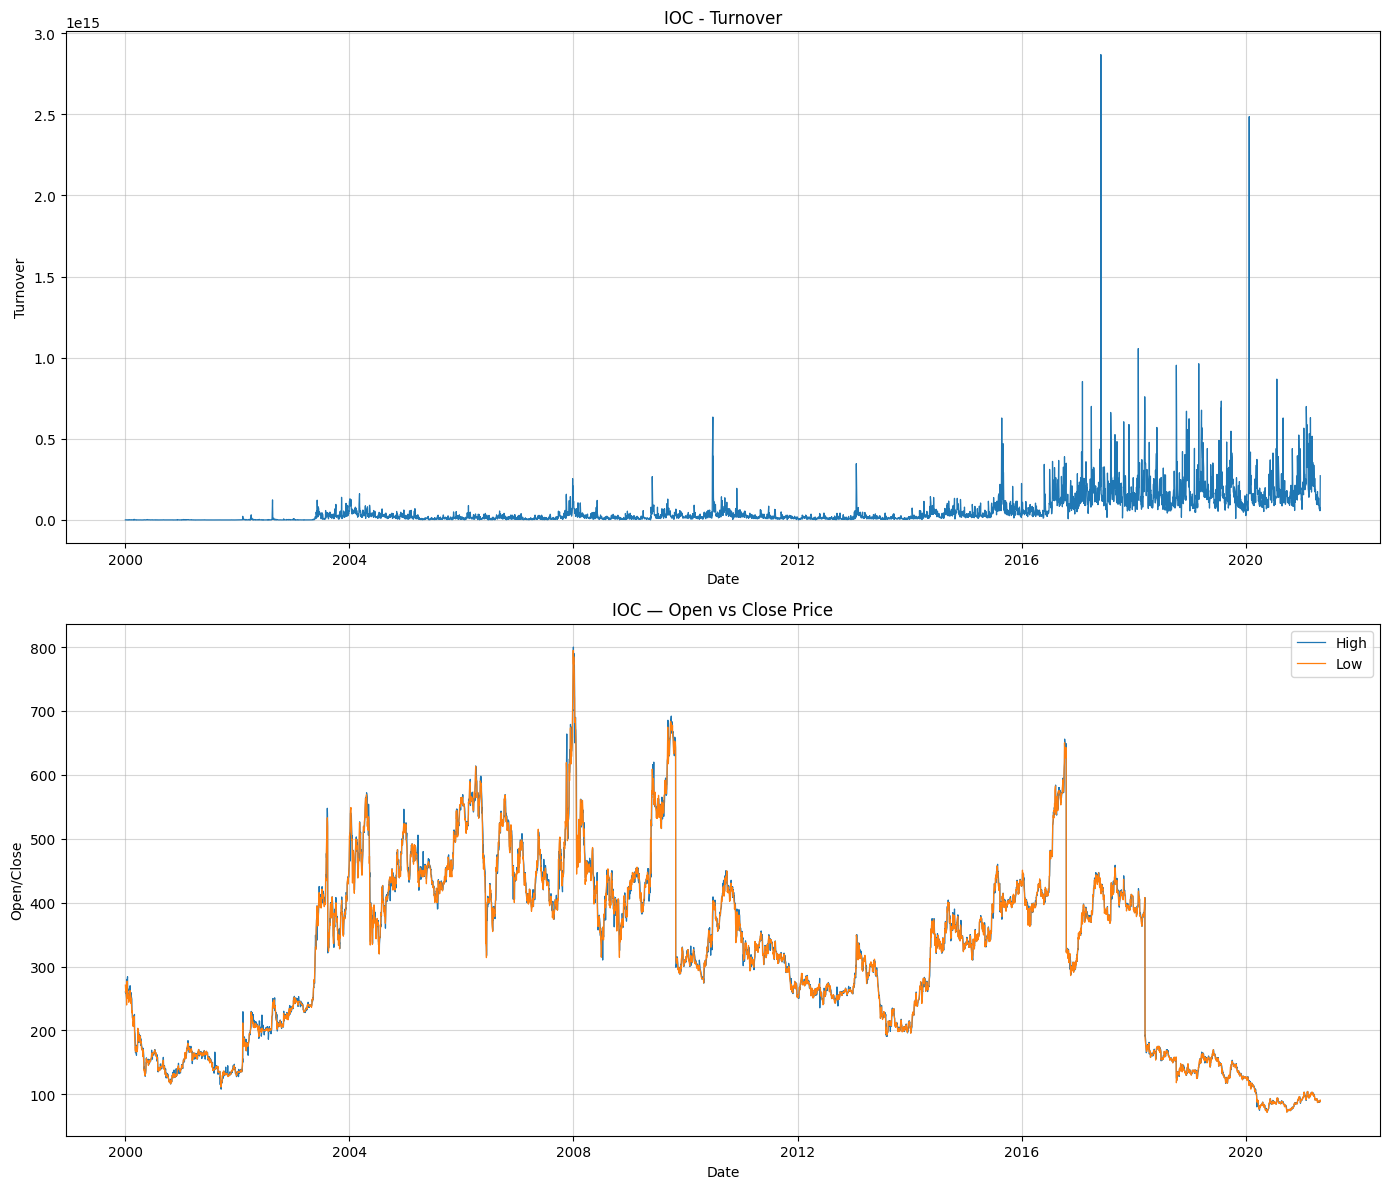

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

axes[0].plot(df['Date'], df['Turnover'],linewidth=0.9)
axes[0].set_title('IOC - Turnover')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Turnover')
axes[0].grid(True, alpha=0.5)


axes[1].plot(df['Date'], df['Open'], linewidth=0.9, label='High')
axes[1].plot(df['Date'], df['Close'], linewidth=0.9, label='Low')
axes[1].set_title('IOC — Open vs Close Price', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Open/Close')
axes[1].legend()
axes[1].grid(True, alpha=0.5)



plt.tight_layout()
plt.show()

### 7. Train-Test-Validation Split

In [64]:
TRAIN_RATIO = 0.8

splitIdx = int(TRAIN_RATIO * len(data))

train_data = data[:splitIdx]
test_data = data[splitIdx:]

val_splitIdx = int(len(train_data) * 0.8)

val_data = train_data[val_splitIdx:]
train_data = train_data[:val_splitIdx]

### 8. Normalization

In [65]:
train_data_norm = normalize(train_data, norm='l2', axis=0)
test_data_norm = normalize(test_data, norm='l2', axis=0)
val_data_norm = normalize(val_data, norm='l2', axis=0)

### 9. Create Time Sequence

In [155]:
INPUT_STEPS = 10
OUTPUT_STEPS = 5
OVERLAP = 8
BATCH_SIZE = 4

def create_sequences(data, input_len=INPUT_STEPS, output_len=OUTPUT_STEPS, overlap=1):
    X, y = [], []
    total_len = len(data)
    stride = input_len - overlap
    
    for i in range(0, total_len - input_len - output_len + 1, stride):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len])
        
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [156]:
X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS, OVERLAP)
X_test, y_test = create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS, OVERLAP)
X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS, OVERLAP)

In [157]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(StockDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

### 10. Define LSTM (RNN Model)

In [168]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=11, hidden_size=64, output_len=OUTPUT_STEPS):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_len * input_size)

        self.output_len = output_len
        self.input_size = input_size

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]        
        out = self.fc(out)        
        out = out.view(-1, self.output_len, self.input_size)
        return out

### 11. Instantiate Model

In [169]:
model = LSTMModel().to(device)
criterion_MSE = nn.MSELoss()
criterion_MAE = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

def RMSELoss(y_pred, y_true):
    mse = nn.MSELoss()(y_pred,y_true)
    rmse = torch.sqrt(mse)
    return rmse

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=10
)

### 12. Method for Training 1 epoch

In [170]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

### 13. Method for evaluation

In [181]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

### 14. Training with Early Stopping

In [182]:
EPOCHS = 100
PATIENCE = 20 
train_losses_MSE = []
val_losses_MSE = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion_MSE, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion_MSE, device)

    train_losses_MSE.append(train_loss)
    val_losses_MSE.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [1/100] | Train Loss: 0.000039 | Val Loss: 0.000164
Epoch [2/100] | Train Loss: 0.000038 | Val Loss: 0.000163
Epoch [3/100] | Train Loss: 0.000039 | Val Loss: 0.000165
Epoch [4/100] | Train Loss: 0.000039 | Val Loss: 0.000163
Epoch [5/100] | Train Loss: 0.000038 | Val Loss: 0.000164
Epoch [6/100] | Train Loss: 0.000038 | Val Loss: 0.000170
Epoch [7/100] | Train Loss: 0.000038 | Val Loss: 0.000166
Epoch [8/100] | Train Loss: 0.000038 | Val Loss: 0.000166
Epoch [9/100] | Train Loss: 0.000038 | Val Loss: 0.000166
Epoch [10/100] | Train Loss: 0.000038 | Val Loss: 0.000165
Epoch [11/100] | Train Loss: 0.000038 | Val Loss: 0.000164
Epoch [12/100] | Train Loss: 0.000038 | Val Loss: 0.000165
Epoch [13/100] | Train Loss: 0.000038 | Val Loss: 0.000165
Epoch [14/100] | Train Loss: 0.000038 | Val Loss: 0.000168
Epoch [15/100] | Train Loss: 0.000038 | Val Loss: 0.000165
Epoch [16/100] | Train Loss: 0.000038 | Val Loss: 0.000164
Epoch [17/100] | Train Loss: 0.000038 | Val Loss: 0.000162
Epoch 

### 15. Test Dataset evaluation

In [183]:
test_loss_MSE, predictions_MSE, targets_MSE = evaluate(model, test_loader, criterion_MSE, device)
print("\nFinal MSE Test Loss:", test_loss_MSE)

test_loss_RMSE, predictions_RMSE, targets_RMSE = evaluate(model, test_loader, RMSELoss, device)
print("\nFinal RMSE Test Loss:", test_loss_RMSE)

test_loss_MAE, predictions_MAE, targets_MAE = evaluate(model, test_loader, criterion_MAE, device)
print("\nFinal MAE Test Loss:", test_loss_MAE)


Final MSE Test Loss: 0.00014326625842625944

Final RMSE Test Loss: 0.008939218159964067

Final MAE Test Loss: 0.004245005434251013


### 16. Plotting Predicted Values vs Target Values 

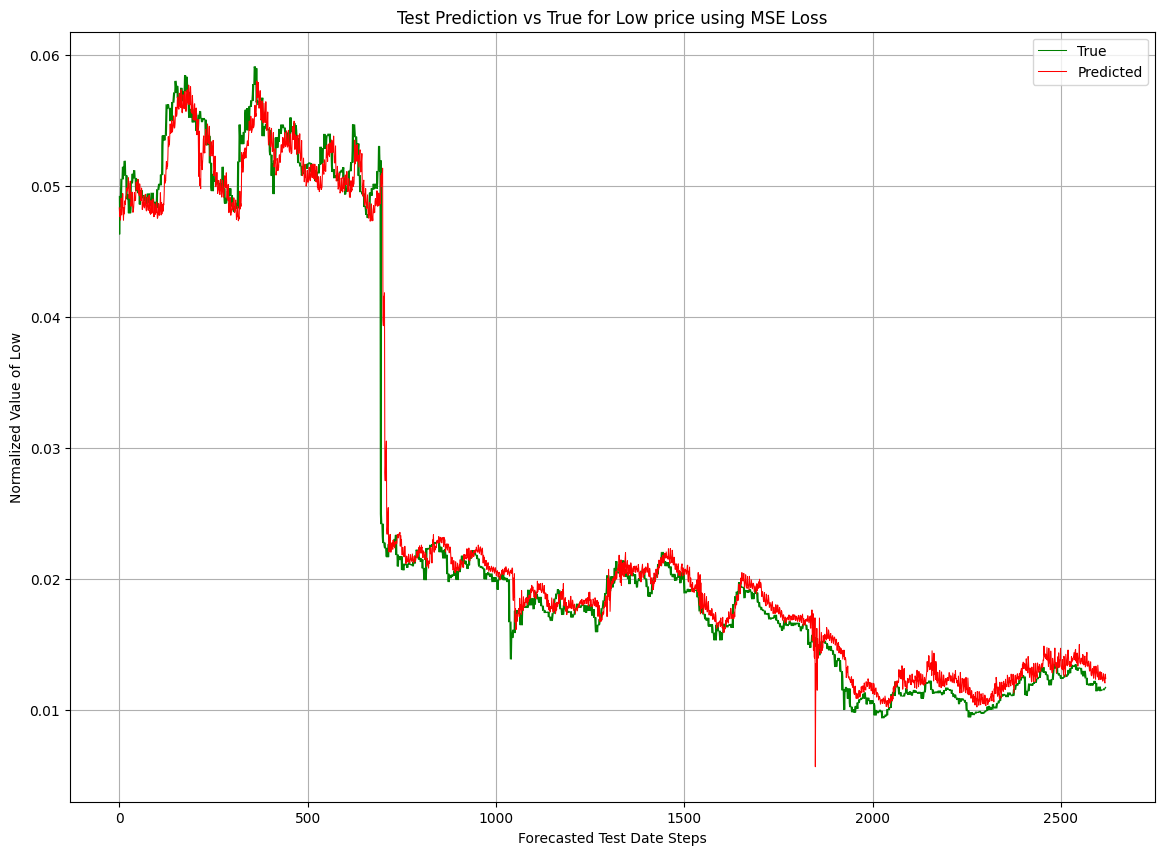

In [187]:
PLOT_FEATURE = "Low" 

feature_idx = features.index(PLOT_FEATURE)

pred_feature = predictions_MSE[:, :, feature_idx].reshape(-1)
true_feature = targets_MSE[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 10))
plt.plot(true_feature, color='green', label="True", linewidth=0.75)
plt.plot(pred_feature, color='red', label="Predicted", linewidth=0.75)

plt.title(f"Test Prediction vs True for {PLOT_FEATURE} price using MSE Loss")
plt.xlabel("Forecasted Test Date Steps")
plt.ylabel(f"Normalized Value of {PLOT_FEATURE}")

plt.legend()
plt.grid(True)
plt.show()

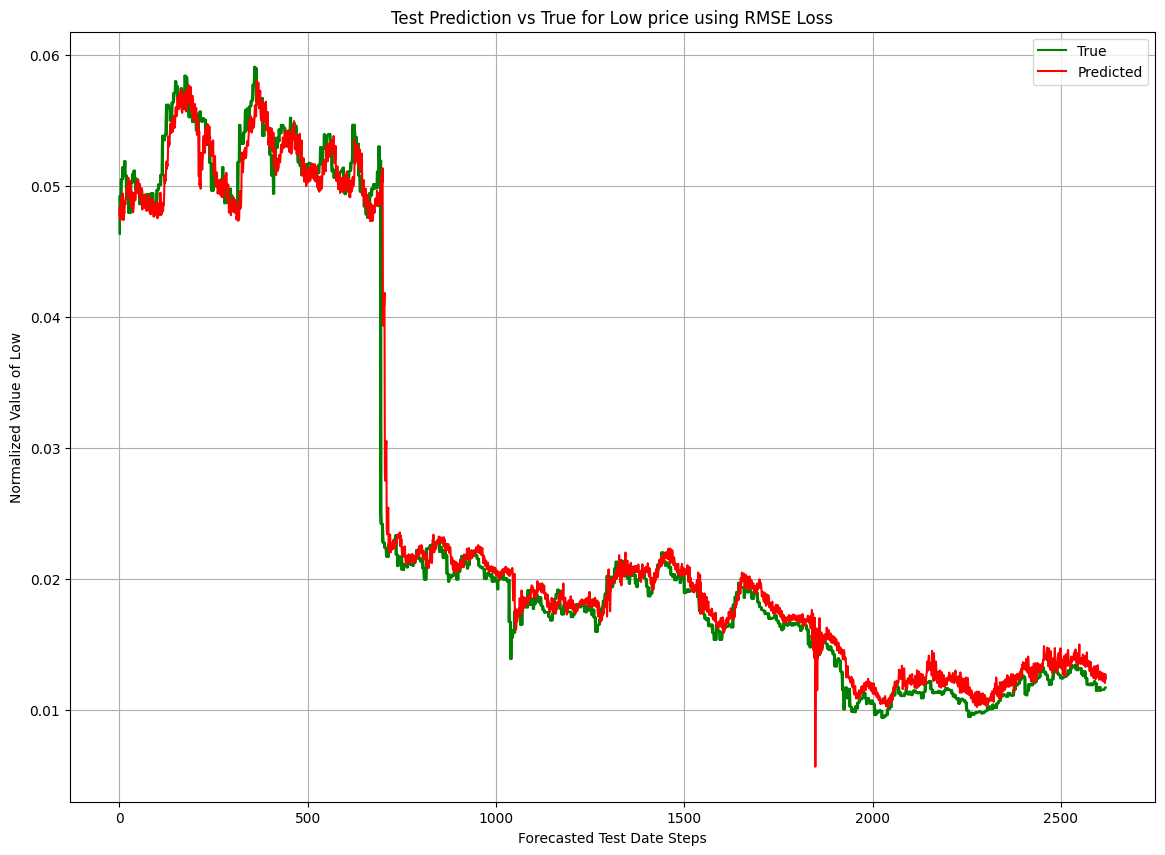

In [189]:
PLOT_FEATURE = "Low" 

feature_idx = features.index(PLOT_FEATURE)

pred_feature = predictions_RMSE[:, :, feature_idx].reshape(-1)
true_feature = targets_RMSE[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 10))
plt.plot(true_feature, color='green', label="True")
plt.plot(pred_feature, color='red', label="Predicted")

plt.title(f"Test Prediction vs True for {PLOT_FEATURE} price using RMSE Loss")
plt.xlabel("Forecasted Test Date Steps")
plt.ylabel(f"Normalized Value of {PLOT_FEATURE}")

plt.legend()
plt.grid(True)
plt.show()

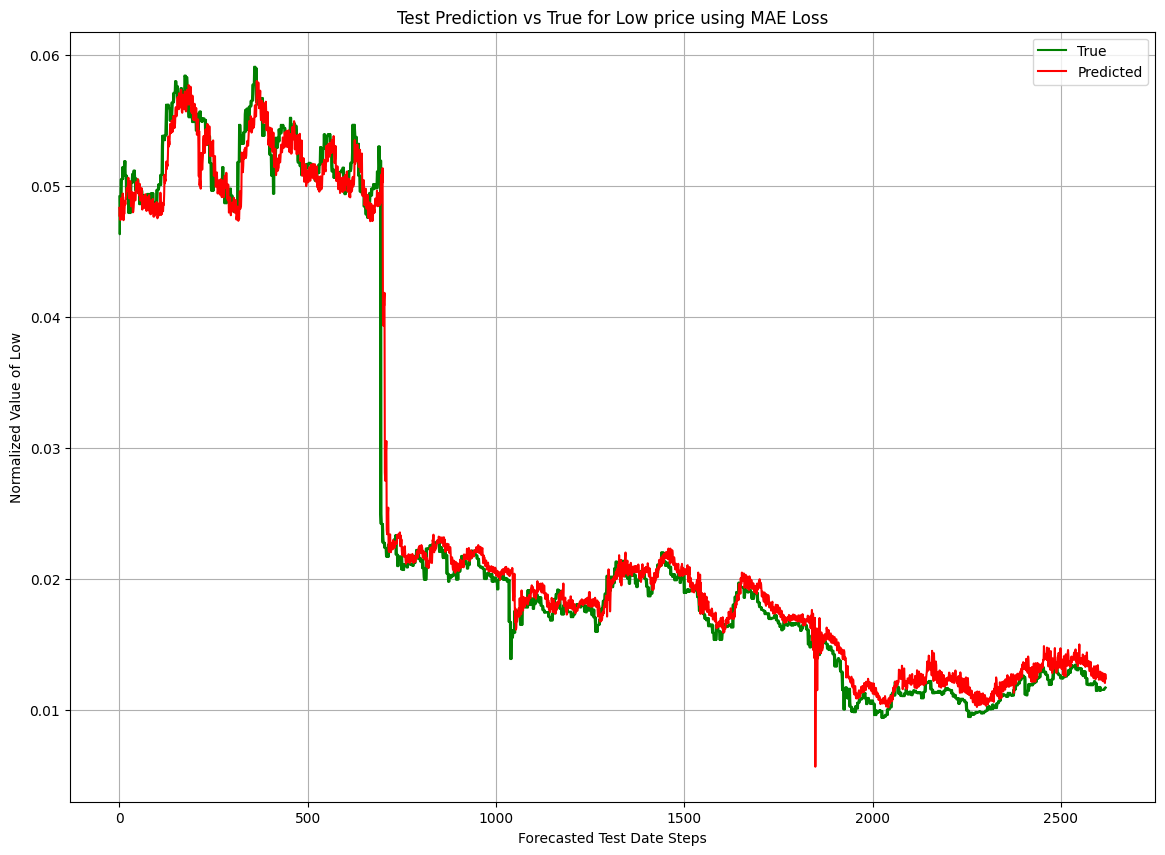

In [190]:
PLOT_FEATURE = "Low" 

feature_idx = features.index(PLOT_FEATURE)

pred_feature = predictions_MAE[:, :, feature_idx].reshape(-1)
true_feature = targets_MAE[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 10))
plt.plot(true_feature, color='green', label="True")
plt.plot(pred_feature, color='red', label="Predicted")

plt.title(f"Test Prediction vs True for {PLOT_FEATURE} price using MAE Loss")
plt.xlabel("Forecasted Test Date Steps")
plt.ylabel(f"Normalized Value of {PLOT_FEATURE}")

plt.legend()
plt.grid(True)
plt.show()

### 17. Plotting Predicted vs Target values of all 11 features for 5 days

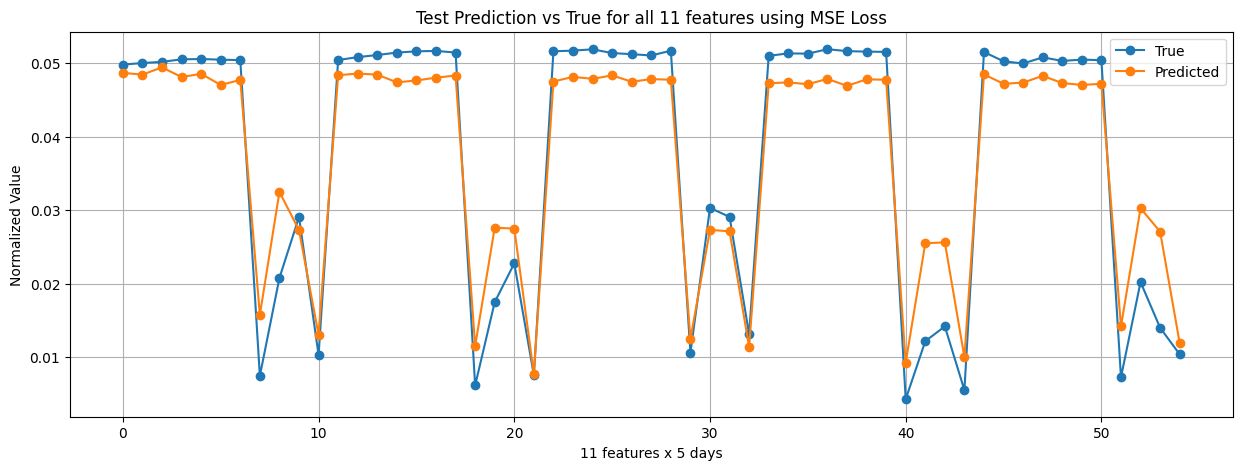

In [191]:
pred_feature = predictions_MSE[2, :, :].reshape(-1)
true_feature = targets_MSE[2, :, :].reshape(-1)

plt.figure(figsize=(15, 5))
plt.plot(true_feature, marker='o', label="True")
plt.plot(pred_feature,  marker='o', label="Predicted")

plt.title(f"Test Prediction vs True for all 11 features using MSE Loss")
plt.xlabel("11 features x 5 days")
plt.ylabel("Normalized Value")

plt.legend()
plt.grid(True)
plt.show()

### 18. Performance Metrics

In [194]:
_, final_preds, final_targets = evaluate(model, test_loader, criterion_MSE,device)

preds_flat   = final_preds.reshape(-1)
targets_flat = final_targets.reshape(-1)

print("-+" * 30)
print(f"  MSE  (Mean Squared Error)       : {test_loss_MSE:.6f}")
print(f"  RMSE (Root Mean Squared Error)  : {test_loss_RMSE:.6f}")
print(f"  MAE  (Mean Absolute Error)      : {test_loss_MAE:.6f}")
print("-+" * 30)

print("\nPer-Feature Metrics:\n")
print(f"{'Feature':<25} {'MSE':>12} {'RMSE':>12} {'MAE':>12}")
print("-" * 66)
for i, feat in enumerate(features):
    p = final_preds[:, :, i].reshape(-1)
    t = final_targets[:, :, i].reshape(-1)
    f_mse  = mean_squared_error(t, p)
    f_rmse = np.sqrt(f_mse)
    f_mae  = mean_absolute_error(t, p)
    print(f"{feat:<25} {f_mse:>12.6f} {f_rmse:>12.6f} {f_mae:>12.6f}")

-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
  MSE  (Mean Squared Error)       : 0.000143
  RMSE (Root Mean Squared Error)  : 0.008939
  MAE  (Mean Absolute Error)      : 0.004245
-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+

Per-Feature Metrics:

Feature                            MSE         RMSE          MAE
------------------------------------------------------------------
Prev Close                    0.000003     0.001830     0.000914
Open                          0.000004     0.002068     0.001142
High                          0.000004     0.002052     0.001142
Low                           0.000004     0.002004     0.001115
Last                          0.000005     0.002134     0.001195
Close                         0.000005     0.002152     0.001200
VWAP                          0.000004     0.002061     0.001146
Volume                        0.000380     0.019487     0.009741
Turnover                      0.000415     0.020372     0.010117
Tra